In [1]:
import pandas as pd

df_encoded = pd.read_csv("rideshare_encoded.csv")


In [2]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (571027, 49)
y shape: (571027,)


In [4]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (456821, 49)
X_test : (114206, 49)
y_train: (456821,)
y_test : (114206,)


In [5]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [6]:
print("Intercept:", lr_model.intercept_)

print("\nCoefficients:")
print(lr_model.coef_)

Intercept: 10.866988774643634

Coefficients:
[ 1.59687621e+01  2.74105187e+01  2.08992652e-03  8.50250576e-03
 -6.21710749e-03  2.71726895e-02 -1.89193624e-02  3.20372315e+00
  9.66122316e+00 -7.02260276e-02  5.11627655e+00  1.37811223e+01
 -8.23452077e+00 -2.52637427e+00 -1.12700010e+01 -1.16192733e+01
 -1.05926727e+01 -4.73763798e+00 -1.05959025e+01 -4.58330755e-01
 -4.52082810e-01 -2.26428276e-01  1.19484554e-01  3.57246284e-01
  5.20328066e-01 -1.34967458e-01 -4.05568711e-01  1.47097946e-01
  3.21262116e-01 -1.10789670e-01 -3.37712720e-01 -1.55923908e-01
 -3.82057995e-01  1.77543347e-01  2.83142189e-01  1.43269608e-01
  9.43808060e-02  6.59279138e-02  1.05049693e-01  2.29035221e-01
 -8.39024627e-02  7.20840009e-02 -7.24380247e-03  1.67107074e-02
  2.87518973e-02 -1.92386374e-04  2.06907796e-02  1.60021620e-02
  1.50279357e-02]


In [7]:
y_pred_lr = lr_model.predict(X_test)

In [8]:
y_pred_lr

array([12.55733795, 15.01532154, 14.50717941, ..., 25.90123155,
       21.11098356, 10.35945796])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("MAE :", mae_lr)

print("R2  :", r2_lr)


# Gradiant Decent

In [25]:
import numpy as np

class GDRegressor:
    def __init__(self, learning_rate=0.01, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs
        self.m = None  
        self.c = None ]
        self.loss_history = []

    def fit(self, X_train, y_train):
        X_mat = np.array(X_train)
        Y_mat = np.array(y_train).reshape(-1, 1)
        n = len(X_mat)
        n_features = X_mat.shape[1]
        
        self.m = np.zeros((n_features, 1))
        self.c = 0.0
        self.loss_history = []
        
        for i in range(self.epochs):
            Y_pred = np.dot(X_mat, self.m) + self.c          
            error = Y_pred - Y_mat                           
            
            loss = (1/n) * np.sum(error ** 2)                 
            self.loss_history.append(loss)
            
            dm = (2/n) * np.dot(X_mat.T, error)              
            dc = (2/n) * np.sum(error)                    
            
            self.m = self.m - self.lr * dm              
            self.c = self.c - self.lr * dc                    
                   
        print(" Intercept:", self.c)
        print(" Coefficients", self.m)

    def predict(self, X_test):
        X_mat = np.array(X_test)
        return np.dot(X_mat, self.m) + self.c


In [36]:
model = GDRegressor(
    learning_rate=0.1,
    epochs=50
)

In [37]:
model.fit(X_train, y_train)


 Intercept (c): 6.3371709121366075
 Coefficients [[6.029240485933239]
 [0.5796050181023489]
 [1.1582436666048275]
 [3.628001218949891]
 [2.5560304832640655]
 [2.622284423694894]
 [0.6404525266919165]
 [0.441447620753195]
 [7.981885481387628]
 [1.4040445271031403]
 [4.299448609880581]
 [8.814417400480218]
 [-3.2603245633759625]
 [0.0006946098066331844]
 [-5.3625572925111955]
 [-4.1525446674533795]
 [-3.4648020441567504]
 [-0.24836176408705618]
 [-3.468511024725437]
 [0.1569821657677937]
 [1.3902628470656255]
 [1.2113739911530985]
 [0.7623352664238568]
 [-0.5546967202600114]
 [0.09763675072178221]
 [0.5035399103050293]
 [1.0341620002815775]
 [0.24476955161436875]
 [0.5827654760318296]
 [0.38285777129976123]
 [0.37280602102722293]
 [1.150317240548935]
 [1.1766550547697605]
 [0.9851697891025012]
 [-0.28599418451213166]
 [-0.044291533219392235]
 [0.6186703122823523]
 [1.0074186604408382]
 [-0.09044274646782263]
 [0.30596258236419244]
 [0.3429255017945053]
 [0.09049704741262368]
 [0.25725648

In [38]:
y_pred = model.predict(X_test)

In [39]:
y_pred

array([[13.252843646444322],
       [16.105271838348525],
       [14.997681697988607],
       ...,
       [20.786655294309885],
       [18.7533263053217],
       [13.394527971688778]], dtype=object)

In [ ]:
print('hello')

In [14]:
y_test

205691    13.5
247008    16.5
56530     13.5
188703    16.5
366198    22.5
          ... 
60711     27.5
83277     11.0
154229    27.5
506577    22.5
32130     10.0
Name: price, Length: 114206, dtype: float64

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred)

r2_lr = r2_score(y_test, y_pred)

print("MAE :", mae_lr)

print("R2  :", r2_lr)

MAE : 3.8709520755172098
R2  : 0.7117038886178757


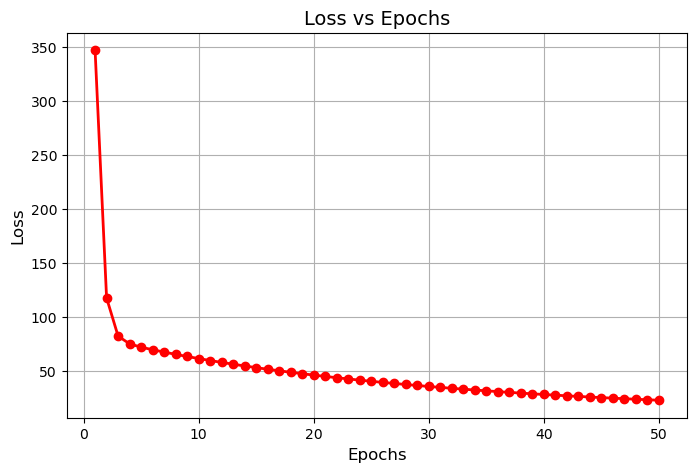

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, model.epochs + 1), model.loss_history, marker='o', color='red', linewidth=2)

plt.title('Loss vs Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.show()
